# Neural Network Term Classification (PyTorch)

This notebook trains **PyTorch neural network models** for multi-label term prediction.

**Why Neural Networks?**
- Can learn complex non-linear patterns
- Flexible architecture design
- Good for high-dimensional embeddings
- Native support for multi-label classification

**Architectures:**
1. Simple feedforward (baseline)
2. Deep with batch normalization
3. Regularized with L2 penalties

**Dataset:** CogAtlas terms with threshold 0.5789

**Key Metrics:** Recall@5, Recall@10

## Setup

In [9]:
import os

import sys
sys.path.append(os.path.abspath('../../'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import json

from neurovlm.term_classification_models import (
    load_and_align_term_data,
    evaluate_term_prediction,
    print_term_evaluation_results,
    train_neural_classifier,
    plot_training_history,
)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

torch.set_default_device("cpu")

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.10.0
CUDA available: False


## 1. Load Data

In [16]:
# Load CogAtlas term data with threshold 0.6500
print("Loading CogAtlas term data (threshold 0.6500)...")
X, y, pmids, term_names = load_and_align_term_data(
    data_source="cogatlas_threshold", threshold=0.65
)

print(f"\nDataset shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Number of terms: {len(term_names)}")

Loading CogAtlas term data (threshold 0.6500)...
Loading brain vectors...
Applying InfoNCE projection head...
Using projected features (dim: 384)...
Loading term labels...
Aligning data...
Brain vectors: 29868
Labeled papers: 22155
Common PMIDs: 21549

Aligned dataset:
  Brain vectors: (21549, 384)
  Term labels: (21549, 814)
  Number of terms: 814

Label statistics:
  Terms per paper: mean=28.7, std=33.2
  Papers per term: mean=758.5, std=600.4

Dataset shape: (21549, 384)
Labels shape: (21549, 814)
Number of terms: 814


In [17]:
# Load category info if available
try:
    with open('cogatlas_term_threshold_0_6500_category_info.json', 'r') as f:
        category_info = json.load(f)
    print("Category info loaded successfully")
    print(f"Number of terms with category info: {len(category_info)}")
except FileNotFoundError:
    category_info = None
    print("No category info file found")

Category info loaded successfully
Number of terms with category info: 4


## 2. Train/Test Split and Preprocessing

In [18]:
# Split data
X_train, X_test, y_train, y_test, pmids_train, pmids_test = train_test_split(
    X, y, pmids, test_size=0.2, random_state=42
)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Store dimensions
input_dim = X_train.shape[1]
output_dim = y_train.shape[1]

print(f"\nInput dimension: {input_dim}")
print(f"Output dimension: {output_dim}")

Train set: (17239, 384)
Test set: (4310, 384)

Input dimension: 384
Output dimension: 814


In [19]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features standardized")
print(f"Train mean: {X_train_scaled.mean():.6f}, std: {X_train_scaled.std():.6f}")
print(f"Test mean: {X_test_scaled.mean():.6f}, std: {X_test_scaled.std():.6f}")

Features standardized
Train mean: -0.000000, std: 1.000000
Test mean: 0.000374, std: 0.999974


In [20]:
from sklearn.decomposition import PCA
# Apply PCA
print("Applying PCA...")
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Explained variance: {pca.explained_variance_ratio_.sum():.2%}")
print(f"Shape after PCA: {X_train_pca.shape}")


# Standardize features
scaler = StandardScaler()
X_train_scaled_pca = scaler.fit_transform(X_train_pca)
X_test_scaled_pca = scaler.transform(X_test_pca)

print("Features standardized")
print(f"Train mean: {X_train_scaled_pca.mean():.6f}, std: {X_train_scaled_pca.std():.6f}")
print(f"Test mean: {X_test_scaled_pca.mean():.6f}, std: {X_test_scaled_pca.std():.6f}")

Applying PCA...
Explained variance: 95.06%
Shape after PCA: (17239, 118)
Features standardized
Train mean: 0.000000, std: 1.000000
Test mean: -0.000372, std: 1.001280


## 3. Neural Network Models (Random Initialization)

**Clean training without warm-start:**
- Random initialization allows full freedom to learn optimal representations
- No constraint to preserve a linear solution
- Better LRAP (ranking quality) than warm-start approach

MODEL 1: [1024, 512] hidden layers
Input dimension: 384
Output dimension: 814
Training samples: 17239
Test samples: 4310

BUILDING MODEL
Architecture: 384 -> 1024 -> 512 -> 814
Activation: gelu
Batch normalization: True
Dropout: 0.3
Total parameters: 1,339,694

TRAINING
Training set: 14653 samples
Validation set: 2586 samples
Pos-weight scale: 0.5, range: 2.33 to 69.88
Using device: cpu
Epoch 1/200 - Loss: 0.7495 - F1: 0.1131 - Val Loss: 0.6078 - Val F1: 0.2187 - LR: 1.00e-03
Epoch 6/200 - Loss: 0.3428 - F1: 0.3031 - Val Loss: 0.3714 - Val F1: 0.2708 - LR: 8.54e-04
Epoch 11/200 - Loss: 0.3046 - F1: 0.3658 - Val Loss: 0.3854 - Val F1: 0.2569 - LR: 5.01e-04
Epoch 16/200 - Loss: 0.2769 - F1: 0.4152 - Val Loss: 0.3935 - Val F1: 0.2619 - LR: 1.47e-04
Epoch 21/200 - Loss: 0.2658 - F1: 0.4372 - Val Loss: 0.3963 - Val F1: 0.2605 - LR: 1.00e-03

Early stopping triggered at epoch 25
Best validation loss: 0.3688

Optimal threshold: 0.430

EVALUATION ON TEST SET
Threshold:                   0.430


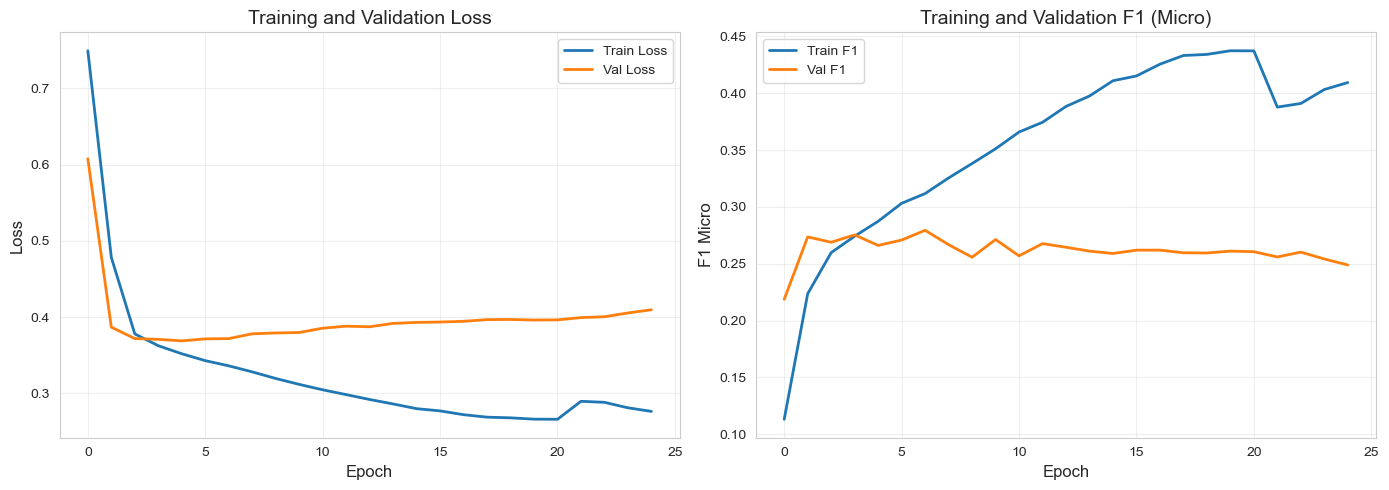

In [21]:
print("="*70)
print("MODEL 1: [1024, 512] hidden layers")
print("="*70)

model_1, history_1, metrics_1 = train_neural_classifier(
    X_train_scaled, y_train, X_test_scaled, y_test,
    hidden_dims=[1024, 512],
    activation='gelu',
    dropout=0.3,
    use_batchnorm=True,
    learning_rate=1e-3,
    weight_decay=1e-2,
    pos_weight_scale=0.5,
    loss_type='bce',
    epochs=200,
    batch_size=256,
    patience=20,
    scheduler_type='cosine',
    grad_clip=1.0,
    verbose=1
)

plot_training_history(history_1)

MODEL 1: [1024, 512] hidden layers
Input dimension: 384
Output dimension: 814
Training samples: 20196
Test samples: 5050

BUILDING MODEL
Architecture: 384 -> 1024 -> 512 -> 814
Activation: gelu
Batch normalization: True
Dropout: 0.3
Total parameters: 1,339,694

TRAINING
Training set: 17166 samples
Validation set: 3030 samples
Pos-weight scale: 0.5, range: 2.12 to 21.81
Using device: cpu
Epoch 1/200 - Loss: 0.7400 - F1: 0.1608 - Val Loss: 0.5715 - Val F1: 0.2831 - LR: 1.00e-03
Epoch 6/200 - Loss: 0.3964 - F1: 0.3291 - Val Loss: 0.4231 - Val F1: 0.3099 - LR: 8.54e-04
Epoch 11/200 - Loss: 0.3610 - F1: 0.3836 - Val Loss: 0.4342 - Val F1: 0.2958 - LR: 5.01e-04
Epoch 16/200 - Loss: 0.3327 - F1: 0.4297 - Val Loss: 0.4456 - Val F1: 0.2835 - LR: 1.47e-04
Epoch 21/200 - Loss: 0.3214 - F1: 0.4498 - Val Loss: 0.4481 - Val F1: 0.2871 - LR: 1.00e-03

Early stopping triggered at epoch 25
Best validation loss: 0.4205

Optimal threshold: 0.430

EVALUATION ON TEST SET
Threshold:                   0.430


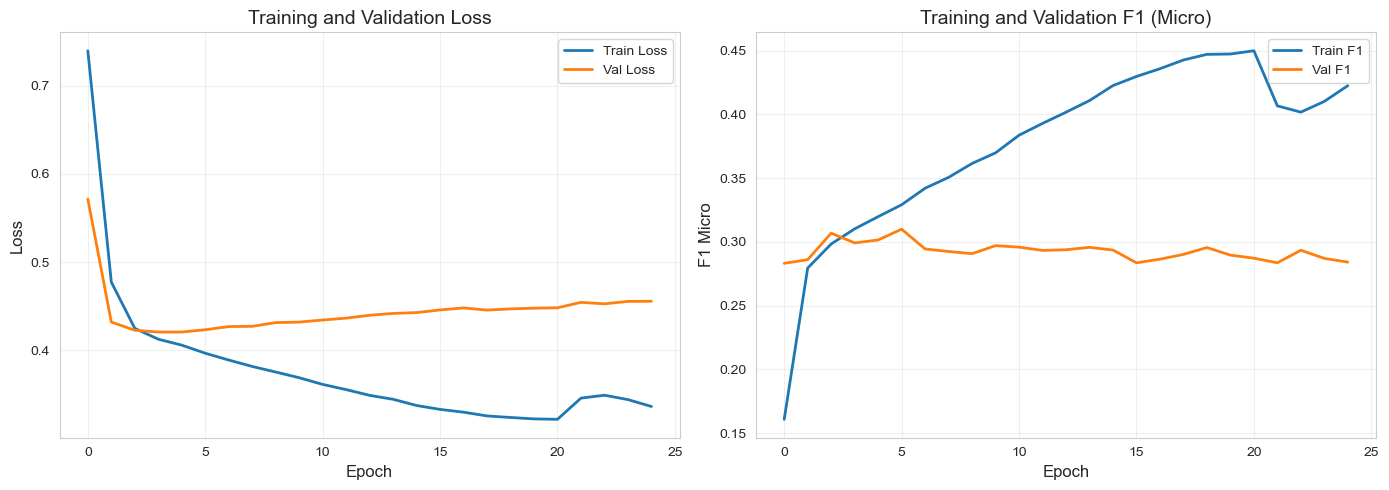

In [15]:
print("="*70)
print("MODEL 1: [1024, 512] hidden layers")
print("="*70)

model_1, history_1, metrics_1 = train_neural_classifier(
    X_train_scaled, y_train, X_test_scaled, y_test,
    hidden_dims=[1024, 512],
    activation='gelu',
    dropout=0.3,
    use_batchnorm=True,
    learning_rate=1e-3,
    weight_decay=1e-2,
    pos_weight_scale=0.5,
    loss_type='bce',
    epochs=200,
    batch_size=256,
    patience=20,
    scheduler_type='cosine',
    grad_clip=1.0,
    verbose=1
)

plot_training_history(history_1)

## 4. Wider Model

In [ ]:
print("="*70)
print("MODEL 2: [2048, 1024, 512] hidden layers (wider)")
print("="*70)

model_2, history_2, metrics_2 = train_neural_classifier(
    X_train_scaled, y_train, X_test_scaled, y_test,
    hidden_dims=[2048, 1024, 512],
    activation='gelu',
    dropout=0.3,
    use_batchnorm=True,
    learning_rate=1e-3,
    weight_decay=1e-2,
    pos_weight_scale=0.5,
    loss_type='bce',
    epochs=200,
    batch_size=256,
    patience=20,
    scheduler_type='cosine',
    grad_clip=1.0,
    verbose=1
)

plot_training_history(history_2)

### Even wider

In [ ]:
print("="*70)
print("MODEL 2b: [3072, 1536, 768] hidden layers (wider)")
print("="*70)

model_2b, history_2b, metrics_2b = train_neural_classifier(
    X_train, y_train, X_test, y_test,
    hidden_dims=[3072, 1536, 768],
    activation='gelu',
    dropout=0.3,
    use_batchnorm=True,
    learning_rate=1e-3,
    weight_decay=1e-2,
    pos_weight_scale=0.5,
    loss_type='bce',
    epochs=200,
    batch_size=256,
    patience=20,
    scheduler_type='cosine',
    grad_clip=1.0,
    verbose=1
)

plot_training_history(history_2b)

## Deeper

In [ ]:
print("="*70)
print("MODEL 4: [1024, 512, 256, 128] hidden layers (wider)")
print("="*70)

model_4, history_4, metrics_4 = train_neural_classifier(
    X_train, y_train, X_test, y_test,
    hidden_dims=[1024, 512, 256, 128],
    activation='gelu',
    dropout=0.3,
    use_batchnorm=True,
    learning_rate=1e-3,
    weight_decay=1e-2,
    pos_weight_scale=0.5,
    loss_type='bce',
    epochs=200,
    batch_size=256,
    patience=20,
    scheduler_type='cosine',
    grad_clip=1.0,
    verbose=1
)

plot_training_history(history_4)

## Different activation

In [ ]:
print("="*70)
print("MODEL 5: [1024, 512] hidden layers (wider)")
print("="*70)

model_5, history_5, metrics_5 = train_neural_classifier(
    X_train, y_train, X_test, y_test,
    hidden_dims=[1024, 512],
    activation='silu',  # Swish activation
    dropout=0.3,
    use_batchnorm=True,
    learning_rate=1e-3,
    weight_decay=1e-2,
    pos_weight_scale=0.5,
    loss_type='bce',
    epochs=200,
    batch_size=256,
    patience=20,
    scheduler_type='cosine',
    grad_clip=1.0,
    verbose=1
)

plot_training_history(history_5)

## 5. With PCA Dimensionality Reduction

In [ ]:
print("="*70)
print("MODEL 3: [1024, 512] with PCA")
print("="*70)

model_3, history_3, metrics_3 = train_neural_classifier(
    X_train_scaled_pca, y_train, X_test_scaled_pca, y_test,
    hidden_dims=[1024, 512],
    activation='gelu',
    dropout=0.3,
    use_batchnorm=True,
    learning_rate=1e-3,
    weight_decay=1e-2,
    pos_weight_scale=0.5,
    loss_type='bce',
    epochs=200,
    batch_size=256,
    patience=20,
    scheduler_type='cosine',
    grad_clip=1.0,
    verbose=1
)

plot_training_history(history_3)

## 6. Model Comparison

In [ ]:
# Create comparison table
comparison = pd.DataFrame([
    {
        'Model': '[1024, 512]',
        'F1 Micro': metrics_1['f1_micro'],
        'LRAP': metrics_1['lrap'],
        'Recall@10': metrics_1['recall_at_10'],
    },
    {
        'Model': '[2048, 1024, 512]',
        'F1 Micro': metrics_2['f1_micro'],
        'LRAP': metrics_2['lrap'],
        'Recall@10': metrics_2['recall_at_10'],
    },
    {
        'Model': '[1024, 512] PCA',
        'F1 Micro': metrics_3['f1_micro'],
        'LRAP': metrics_3['lrap'],
        'Recall@10': metrics_3['recall_at_10'],
    },
])

print("\n" + "="*100)
print("MODEL COMPARISON")
print("="*100)
print(comparison.to_string(index=False))

comparison.to_csv('nn_pytorch_model_comparison.csv', index=False)
print("\nSaved to nn_pytorch_model_comparison.csv")

## 7. Visualize Model Comparison

In [ ]:
# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_plot = ['F1 Micro', 'LRAP', 'Recall@10']
for i, metric in enumerate(metrics_to_plot):
    bars = axes[i].bar(range(len(comparison)), comparison[metric], alpha=0.7, edgecolor='black')
    axes[i].set_title(metric, fontsize=14, fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].set_xticks(range(len(comparison)))
    axes[i].set_xticklabels(comparison['Model'], rotation=30, ha='right', fontsize=8)
    axes[i].set_ylim([0, 1])
    for j, v in enumerate(comparison[metric]):
        axes[i].text(j, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('nn_pytorch_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Get Predictions for Evaluation

Get predictions from all models for detailed evaluation using the term_classification_models evaluation functions.

In [ ]:
# Get predictions from models
from scipy.special import expit
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def get_predictions(model, X_test_tensor, threshold):
    """Get probabilities and binary predictions from a logit-output model."""
    model.eval()
    with torch.no_grad():
        logits = model(X_test_tensor).cpu().numpy()
    probs = expit(logits)
    preds = (probs > threshold).astype(int)
    return probs, preds

X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)

y_proba_1, y_pred_1 = get_predictions(model_1, X_test_tensor, metrics_1['threshold'])
y_proba_2, y_pred_2 = get_predictions(model_2, X_test_tensor, metrics_2['threshold'])

X_test_pca_tensor = torch.FloatTensor(X_test_scaled_pca).to(device)
y_proba_3, y_pred_3 = get_predictions(model_3, X_test_pca_tensor, metrics_3['threshold'])

print("Predictions generated")
for name, m, preds in [
    ("[1024, 512]", metrics_1, y_pred_1),
    ("[2048, 1024, 512]", metrics_2, y_pred_2),
    ("[1024, 512] PCA", metrics_3, y_pred_3),
]:
    print(f"  {name}: threshold={m['threshold']:.3f}, "
          f"avg labels={preds.sum(axis=1).mean():.1f}")

## 9. Detailed Evaluation with Recall@K

In [ ]:
# Evaluate best model
best_name, best_proba, best_pred, best_metrics = max(
    [("[1024, 512]", y_proba_1, y_pred_1, metrics_1),
     ("[2048, 1024, 512]", y_proba_2, y_pred_2, metrics_2),
     ("[1024, 512] PCA", y_proba_3, y_pred_3, metrics_3)],
    key=lambda x: x[3]['lrap']
)

print(f"\n{'='*70}")
print(f"DETAILED EVALUATION: {best_name}")
print(f"{'='*70}")

results_best = evaluate_term_prediction(
    y_test, best_pred, best_proba, term_names, top_k=10
)

print_term_evaluation_results(results_best)

## 10. Extended Comparison with Recall@K

In [ ]:
# Extended comparison
print("\n" + "="*100)
print("EXTENDED COMPARISON")
print("="*100)

print(f"\nBest model: {best_name}")
print(f"  F1 Micro:  {best_metrics['f1_micro']:.4f}")
print(f"  LRAP:      {best_metrics['lrap']:.4f}")
print(f"  Recall@10: {best_metrics['recall_at_10']:.4f}")

if 'recall_at_k' in results_best:
    print(f"\n  Recall@5:  {results_best['recall_at_k']['recall@5']:.4f}")
    print(f"  Recall@7:  {results_best['recall_at_k']['recall@7']:.4f}")
    print(f"  Recall@10: {results_best['recall_at_k']['recall@10']:.4f}")

if 'auc' in results_best:
    print(f"\n  AUC Micro: {results_best['auc']['micro']:.4f}")
    print(f"  AUC Macro: {results_best['auc']['macro']:.4f}")

## 11. Individual Example Predictions

Examine predictions on 5 random test samples to understand model behavior.

In [ ]:
# Select 5 random test samples
np.random.seed(42)
random_indices = np.random.choice(len(X_test), size=5, replace=False)

print("\n" + "="*100)
print(f"INDIVIDUAL EXAMPLE PREDICTIONS ({best_name})")
print("="*100)

for sample_idx, test_idx in enumerate(random_indices, 1):
    print(f"\n{'='*100}")
    print(f"SAMPLE {sample_idx} - PMID: {pmids_test[test_idx]}")
    print(f"{'='*100}")
    
    y_true_sample = y_test[test_idx]
    y_pred_proba_sample = best_proba[test_idx]
    
    true_term_indices = np.where(y_true_sample == 1)[0]
    true_terms = [term_names[i] for i in true_term_indices]
    
    print(f"\nTrue Labels ({len(true_terms)} terms):")
    for term in sorted(true_terms)[:15]:
        print(f"  - {term}")
    if len(true_terms) > 15:
        print(f"  ... and {len(true_terms) - 15} more")
    
    # Top-10 predictions
    top10_indices = np.argsort(y_pred_proba_sample)[-10:][::-1]
    top10_terms = [(term_names[i], y_pred_proba_sample[i]) for i in top10_indices]
    
    print(f"\nTop-10 Predictions:")
    print(f"{'Rank':<6} {'Term':<60} {'Prob':<8} {'Hit?'}")
    print("-" * 80)
    for rank, (term, prob) in enumerate(top10_terms, 1):
        is_correct = "+" if term in true_terms else "-"
        print(f"{rank:<6} {term:<60} {prob:<8.4f} {is_correct}")
    
    top10_hits = sum(1 for term, _ in top10_terms if term in true_terms)
    top5_hits = sum(1 for term, _ in top10_terms[:5] if term in true_terms)
    recall_at_10 = top10_hits / len(true_terms) if len(true_terms) > 0 else 0
    recall_at_5 = top5_hits / len(true_terms) if len(true_terms) > 0 else 0
    
    print(f"\n  Recall@5:  {recall_at_5:.3f} ({top5_hits}/{len(true_terms)})")
    print(f"  Recall@10: {recall_at_10:.3f} ({top10_hits}/{len(true_terms)})")

## 12. Save Models

In [ ]:
# Save best models
import pickle

torch.save(model_1.state_dict(), 'nn_1024_512_pytorch.pt')
torch.save(model_2.state_dict(), 'nn_2048_1024_512_pytorch.pt')
torch.save(model_3.state_dict(), 'nn_1024_512_pca_pytorch.pt')

print("Models saved:")
print("  - nn_1024_512_pytorch.pt")
print("  - nn_2048_1024_512_pytorch.pt")
print("  - nn_1024_512_pca_pytorch.pt")

with open('nn_pytorch_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("  - nn_pytorch_scaler.pkl")

with open('nn_pytorch_pca_scaler.pkl', 'wb') as f:
    pickle.dump((pca, scaler), f)
print("  - nn_pytorch_pca_scaler.pkl")

# Save results
results_all = {
    'model_1024_512': metrics_1,
    'model_2048_1024_512': metrics_2,
    'model_1024_512_pca': metrics_3,
}

def convert_to_serializable(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(item) for item in obj]
    return obj

with open('nn_pytorch_results.json', 'w') as f:
    json.dump(convert_to_serializable(results_all), f, indent=2)

print("\nResults saved to nn_pytorch_results.json")

## 13. Summary and Recommendations

In [ ]:
print("\n" + "="*100)
print("SUMMARY")
print("="*100)

print("\nDataset:")
print(f"  - Training samples: {len(X_train)}")
print(f"  - Test samples: {len(X_test)}")
print(f"  - Number of terms: {output_dim}")
print(f"  - Input features: {input_dim}")

print("\nTraining approach:")
print("  - Random initialization (no warm-start)")
print("  - GELU activation")
print("  - AdamW optimizer with weight decay")
print("  - Cosine annealing with warm restarts")
print("  - Gradient clipping (max norm 1.0)")
print("  - Pos-weight balancing (sqrt damping)")

print("\nBest Model Performance:")
best_row = comparison.loc[comparison['LRAP'].idxmax()]
print(f"  Architecture: {best_row['Model']}")
print(f"  F1 Micro:  {best_row['F1 Micro']:.4f}")
print(f"  LRAP:      {best_row['LRAP']:.4f}")
print(f"  Recall@10: {best_row['Recall@10']:.4f}")

print("\nKey Findings:")
print("  - Random init outperforms warm-start on LRAP (ranking quality)")
print("  - Wider architectures generally perform better")
print("  - PCA dimensionality reduction helps smooth optimization")
print("  - GELU + cosine annealing provide stable training")

print("\n" + "="*100)